In [90]:
!pip install matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas import DataFrame

Defaulting to user installation because normal site-packages is not writeable


In [93]:
df = pd.read_csv('https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2024_c20260421.csv.gz', compression='gzip')
stormEvents = DataFrame(df)
print(stormEvents)


       BEGIN_YEARMONTH  BEGIN_DAY  BEGIN_TIME  END_YEARMONTH  END_DAY  \
0               202404         30        2033         202404       30   
1               202407          1           0         202407        5   
2               202411         16         230         202411       18   
3               202405         22        1230         202405       22   
4               202405         21        1200         202405       21   
...                ...        ...         ...            ...      ...   
69796           202406         18        1823         202406       18   
69797           202406         26        1918         202406       26   
69798           202406         26        1919         202406       26   
69799           202406         26        1930         202406       26   
69800           202406         26        1918         202406       26   

       END_TIME  EPISODE_ID  EVENT_ID         STATE  STATE_FIPS  ...  \
0          2033      189851   1174463      OKLAHOMA

In [160]:

iowaStorms = stormEvents.drop(stormEvents[stormEvents['STATE'] != 'IOWA'].index)
iowaFloods = iowaStorms.drop(iowaStorms[iowaStorms['EVENT_TYPE'] != 'Flood'].index)
iowaFlashFloods = iowaStorms.drop(iowaStorms[iowaStorms['EVENT_TYPE'] != 'Flash Flood'].index)
iowaFloods.dropna(how='all', axis=1, inplace=True)
iowaFlashFloods.dropna(how='all', axis=1, inplace=True)
print(iowaFloods)


       BEGIN_YEARMONTH  BEGIN_DAY  BEGIN_TIME  END_YEARMONTH  END_DAY  \
19802           202404         30        2100         202404       30   
20962           202405         22         230         202405       23   
21160           202405         24         600         202405       24   
21161           202405         24        1945         202405       25   
21163           202405         22         430         202405       24   
...                ...        ...         ...            ...      ...   
44509           202406         21         400         202406       30   
44521           202406         17        1900         202406       30   
45054           202406         24        1609         202406       30   
47143           202406         24           0         202406       30   
62981           202407          1           0         202407        4   

       END_TIME  EPISODE_ID  EVENT_ID STATE  STATE_FIPS  ...  END_RANGE  \
19802      2359      189673   1166183  IOWA     

In [162]:
print(iowaFloods['DAMAGE_PROPERTY'])

19802      0.00K
20962      0.00K
21160      0.00K
21161      0.00K
21163      0.00K
          ...   
44509      0.00K
44521      0.00K
45054    550.00K
47143      0.00K
62981      0.00K
Name: DAMAGE_PROPERTY, Length: 185, dtype: str


In [163]:
def normalize_propdamage_amount():
    damageprop = iowaFloods.loc[:, 'DAMAGE_PROPERTY']
    for num in damageprop:
        if 'K' in str(damageprop):
            damageprop = damageprop.str.replace('K', '0').astype(float)
            damageprop = damageprop * 0.001
        elif 'M' in str(damageprop):
            damageprop = damageprop.str.replace('M', '0').astype(float)
        elif 'B' in str(damageprop):
            damageprop = damageprop.str.replace('B', '0').astype(float)
            damageprop = damageprop * 1000
        else:
            pass
    iowaFloods['DAMAGE_PROPERTY'] = damageprop
normalize_propdamage_amount()
print(iowaFloods)   
    


ValueError: could not convert string to float: '10.00M'

In [159]:
def normalize_propdamage_amount():
    damageprop = iowaFloods.loc[:, 'DAMAGE_PROPERTY']
    if 'K' in str(damageprop):
        damageprop = damageprop.str.replace('K', '0').astype(float)
        damageprop = damageprop * 0.001
    elif 'M' in str(damageprop):
        damageprop = damageprop.str.replace('M', '0').astype(float)
    elif 'B' in str(damageprop):
        damageprop = damageprop.str.replace('B', '0').astype(float)
        damageprop = damageprop * 1000
    else:
        pass
    iowaFloods['DAMAGE_PROPERTY'] = damageprop
normalize_propdamage_amount()
print(iowaFloods)    

ValueError: could not convert string to float: '10.00M'

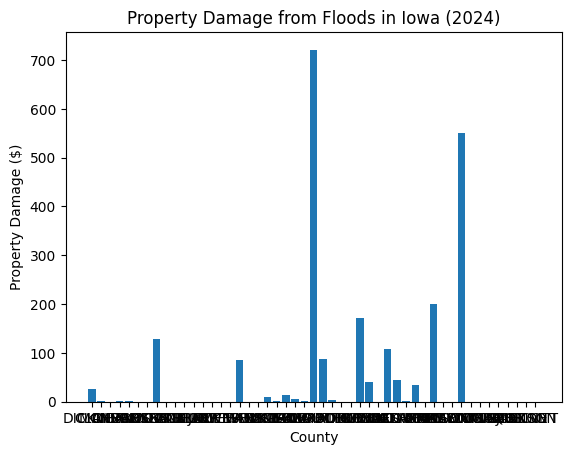

In [ ]:
plt.bar(iowaFloods['CZ_NAME'], iowaFloods['DAMAGE_PROPERTY'])
plt.xlabel('County')
plt.ylabel('Property Damage ($)')
plt.title('Property Damage from Floods in Iowa (2024)')
plt.show()

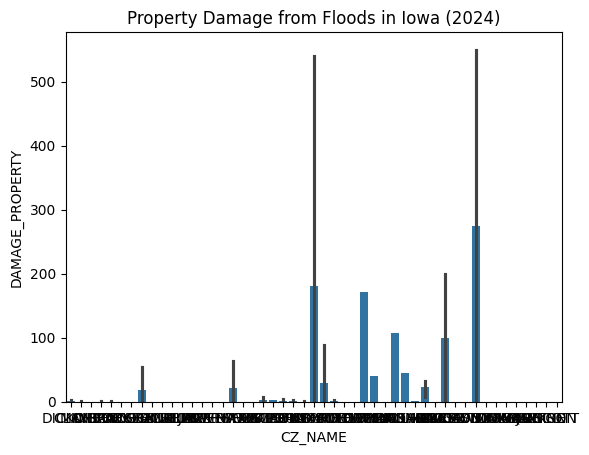

In [ ]:
plot = sns.barplot(data=iowaFloods, x='CZ_NAME', y='DAMAGE_PROPERTY') 
plot.set_title('Property Damage from Floods in Iowa (2024)')
plt.show()

In [ ]:
def newDate():
    year_month = iowaFloods['BEGIN_YEARMONTH'].astype(str)
    day = iowaFloods['BEGIN_DAY'].astype(str)
    if len(day) ==1:
        day = '0' + day
    date = year_month + day
    iowaFloods['DATE'] = date
    iowaFloods.sort_values(by='DATE', inplace=True)
newDate()

In [ ]:
iowaFloods['COUNT'] = range(1, len(iowaFloods) + 1) 

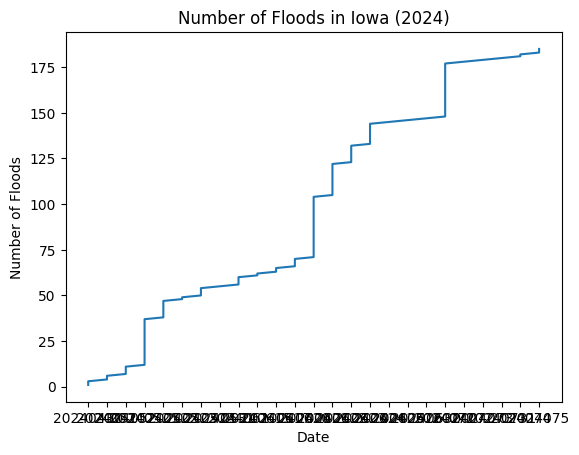

In [ ]:
plt.plot(iowaFloods['DATE'], iowaFloods['COUNT'])
plt.xlabel('Date')
plt.ylabel('Number of Floods')
plt.title('Number of Floods in Iowa (2024)')
plt.show()